# **ExoplanetHunter**
**Entrega 2 - Pré-processamento**

## 1. Objetivo e relação com a Entrega 1
Avaliamos como imputação, escala e redução de atributos afetam um classificador kNN fixo. A referência é `01_eda.ipynb`, preservada com seus resultados. Esta entrega utiliza seu snapshot e seu recorte de 12 grandezas, sem repetir a exploração nem copiar suas células. A EDA não definiu uma seleção definitiva para modelagem; aqui adotamos explicitamente as 12 entradas que ela explorou.

## 2. Características que motivam o experimento
A EDA documentou 9.564 objetos, 153 colunas e 8.214 estrelas, extraídos da tabela KOI Cumulative do NASA Exoplanet Archive em 30/09/2026 (`SELECT * FROM cumulative`). Há 4.839 falsos positivos e 4.725 candidatos/confirmados. As classes próximas de 50% não motivam balanceamento.

Há ausências conjuntas em oito medidas físicas nos mesmos 363 objetos, além de ausências em insolação e magnitude. Remover linhas poderia alterar a representação das classes. Caudas extensas e unidades muito diferentes motivam comparar escala e média/mediana. As associações temperatura de equilíbrio × insolação e gravidade × raio estelar motivam testar redução. Extremos pelo IQR não comprovam erros: preservamos todas as linhas, sem logaritmos, cortes ou correções adicionais. As 24 colunas vazias e 11 constantes do catálogo completo já estão fora deste recorte; não são etapas adicionais do experimento.

## 3. Alvo e atributos preditores
O alvo mantém **0 = FALSE POSITIVE** e **1 = CANDIDATE ou CONFIRMED**. Avaliamos essa classificação do catálogo; candidatos não equivalem a planetas confirmados e uma previsão positiva não confirma um planeta.

| Grupo | Atributos |
|---|---|
| Trânsito | `koi_period`, `koi_impact`, `koi_duration`, `koi_depth` |
| Objeto e sinal | `koi_prad`, `koi_teq`, `koi_insol`, `koi_model_snr` |
| Estrela | `koi_steff`, `koi_slogg`, `koi_srad`, `koi_kepmag` |

As 12 grandezas conservam seus significados e unidades da EDA. Usamos uma lista explícita de preditores: `kepid` serve somente para grupos; `target`, `koi_disposition`, outras classificações, score, flags, comentários e nomes não entram no modelo. Antes da redução, exigimos pelo menos 1.001 instâncias e 11 preditores.

## 4. Opções e espaço experimental
| Etapa | Opções fixadas antes da comparação | Justificativa |
|---|---|---|
| Imputação | Média; mediana | Preservar registros; testar sensibilidade às caudas |
| Encoding | Omitido | As 12 entradas são numéricas contínuas |
| Escala | Nenhuma; StandardScaler; MinMaxScaler; RobustScaler | kNN depende de distâncias; testar unidades e influência de extremos |
| Balanceamento | Omitido | 50,60% / 49,40% no alvo da EDA |
| Redução | Nenhuma; PCA 95%; SelectKBest ANOVA com 8 entradas | Avaliar redundância e seleção supervisionada |

São **2 × 4 × 3 = 24 combinações**. Encoding e balanceamento são omitidos como etapas não aplicáveis ou não justificadas neste recorte, conforme permitido pelo enunciado. StandardScaler usa média/desvio; MinMaxScaler usa extremos [0,1]; RobustScaler usa mediana/IQR (quantis 25 e 75), mas não elimina extremos.

O baseline é **mediana → sem escala → sem redução → kNN(7)**. Ele também imputa, pois o kNN não aceita ausências. PCA usa `n_components=0.95`, `svd_solver='full'`, `whiten=False`: retém no mínimo 95% da variância do treino, com dimensão variável por fold. SelectKBest usa `f_classif`, `k=8`: avalia associação univariada com o alvo do treino, sem capturar todas as interações. Esses parâmetros não serão escolhidos a partir dos resultados. PCA sem escala pode preservar principalmente atributos com grande amplitude, em vez da informação mais útil para classificar.

## 5. Protocolo experimental
Usamos **StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=42)**, agrupado por `kepid`. As cinco divisões são geradas uma única vez e reutilizadas. A EDA mencionou 10 folds para uma etapa futura; esta entrega segue os **cinco folds** do enunciado atual. Salvamos a associação de cada objeto ao fold de teste, que determina exatamente os conjuntos de treino (demais folds).

Ordem fixa: **imputação → escala opcional → redução opcional → kNN**. Um pipeline novo recebe `fit` exclusivamente no treino de cada fold, inclusive para PCA e seleção supervisionada. Não há transformação global. O teste recebe apenas `predict` e `predict_proba`.

kNN: `n_neighbors=7`, `weights='uniform'`, `metric='minkowski'`, `p=2` (euclidiana), `algorithm='brute'`, `n_jobs=1`. Não fazemos busca de hiperparâmetros. Limitamos as threads numéricas a uma durante cada execução para reduzir variação de custo.

Acurácia, precisão, revocação e F1 usam previsões; precisão, revocação e F1 usam classe positiva 1. AUC usa probabilidade da classe 1. Erros de métrica, inclusive classe única ou precisão indefinida, invalidam o fold e são registrados. Médias e desvios amostrais (`ddof=1`) só são apresentados com cinco folds válidos. Tempo inclui ajuste, previsões, métricas e registro dimensional, sem leitura, gráficos ou gravação. Não é um benchmark de hardware.

A comparação é descritiva, sem métrica escolhida após observar o vencedor: reportamos todas e usamos F1 para ordenar as tabelas por combinar precisão e revocação. Para cada métrica, diferenças menores que o **maior dos desvios dos dois métodos** são tratadas como empate; é uma regra conservadora de interpretação, não um teste formal de significância. Folds compartilham treinos e não são cinco amostras independentes.

## 6. Imports, leitura e validação

In [1]:
from pathlib import Path
from hashlib import sha256
from importlib.metadata import version
import sys
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display
from sklearn.model_selection import StratifiedGroupKFold

ROOT = Path.cwd() if (Path.cwd() / 'data').is_dir() else Path.cwd().parent
assert (ROOT / 'src' / 'pipelines.py').exists(), 'Execute na raiz ou em notebooks/.'
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))
from src.pipelines import FEATURES, SEED, BASELINE, METRICS, combinations, build_pipeline
from src.experiments import run_experiment, summarize

pd.set_option('display.max_columns', 30)
pd.set_option('display.max_rows', 30)
CSV = ROOT / 'data' / 'cumulative.csv'
assert CSV.exists(), f'Snapshot ausente: forneça o CSV da Entrega 1 em {CSV}; não baixar outra versão.'
DATA_HASH = sha256(CSV.read_bytes()).hexdigest()
assert DATA_HASH == 'a85348f20082d24fb14d4a05a9a44c644b801998fad7cec36f8980eb1f0a69ab', 'Snapshot diferente da EDA.'
EDA_HASH = sha256((ROOT / 'notebooks' / '01_eda.ipynb').read_bytes()).hexdigest()
raw = pd.read_csv(CSV)
assert raw.shape == (9564, 153)
assert raw['koi_disposition'].value_counts().to_dict() == {'FALSE POSITIVE': 4839, 'CONFIRMED': 2748, 'CANDIDATE': 1977}
assert raw['kepid'].notna().all() and raw['kepid'].nunique() == 8214
assert raw['kepoi_name'].nunique() == 9564
mapping = {'FALSE POSITIVE': 0, 'CANDIDATE': 1, 'CONFIRMED': 1}
y = raw['koi_disposition'].map(mapping)
assert y.notna().all()
y = y.astype(int)
X = raw.loc[:, FEATURES].copy()
groups = raw['kepid'].copy()
assert X.shape == (9564, 12) and len(X) >= 1001 and X.shape[1] >= 11
assert all(pd.api.types.is_numeric_dtype(X[c]) for c in FEATURES)
assert not np.isinf(X.to_numpy()).any()
assert not X.isna().all().any()
assert y.value_counts().to_dict() == {0: 4839, 1: 4725}
versions = {'python': sys.version.split()[0], **{m: version(m) for m in ['numpy', 'pandas', 'matplotlib', 'scikit-learn', 'scipy', 'joblib', 'threadpoolctl', 'nbformat', 'nbclient', 'ipykernel']}}
print('CSV:', CSV.relative_to(ROOT), '| SHA-256:', DATA_HASH)
print('Entrada:', X.shape, '| Semente:', SEED)
display(pd.Series(versions, name='Versão instalada').to_frame())
display(pd.DataFrame({'ausentes': X.isna().sum(), 'percentual_ausente': X.isna().mean()*100}))
display(y.value_counts().sort_index().rename('quantidade').to_frame().assign(percentual=lambda t: t.quantidade/len(y)*100))

CSV: data\cumulative.csv | SHA-256: a85348f20082d24fb14d4a05a9a44c644b801998fad7cec36f8980eb1f0a69ab
Entrada: (9564, 12) | Semente: 42


,Versão instalada
python,3.11.9
numpy,2.1.3
pandas,2.2.3
matplotlib,3.9.2
scikit-learn,1.9.1
scipy,1.17.1
joblib,1.6.0
threadpoolctl,3.7.0
nbformat,5.11.1
nbclient,0.11.0


,ausentes,percentual_ausente
koi_period,0,0.000000
koi_impact,363,3.795483
koi_duration,0,0.000000
koi_depth,363,3.795483
koi_prad,363,3.795483
koi_teq,363,3.795483
koi_steff,363,3.795483
koi_slogg,363,3.795483
koi_srad,363,3.795483
koi_insol,321,3.356336


,quantidade,percentual
koi_disposition,,
0,4839,50.595985
1,4725,49.404015


As verificações exigem o mesmo arquivo congelado (hash, dimensões, identificadores e classes), sem consulta à internet. A tabela de ausências confirma a necessidade da imputação, mantendo as 12 entradas; a distribuição confirma a decisão de omitir balanceamento. As versões acima são lidas do ambiente, não supostas. Nenhuma estatística desta conferência é aplicada como transformação ao modelo.

## 7. Criação e validação das divisões

In [2]:
splitter = StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=SEED)
splits = list(splitter.split(X, y, groups))
assert len(splits) == 5
fold_info = []
assignment = np.zeros(len(X), dtype=int)
for fold, (train, test) in enumerate(splits, 1):
    shared = set(groups.iloc[train]) & set(groups.iloc[test])
    assert not shared
    assert set(train).isdisjoint(test) and len(train)+len(test) == len(X)
    assert y.iloc[train].nunique() == y.iloc[test].nunique() == 2
    assert not assignment[test].any()
    assignment[test] = fold
    fold_info.append({'fold': fold, 'n_train': len(train), 'n_test': len(test),
                      'groups_train': groups.iloc[train].nunique(), 'groups_test': groups.iloc[test].nunique(),
                      'shared_groups': len(shared), 'positive_train': y.iloc[train].mean(),
                      'positive_test': y.iloc[test].mean(),
                      'negative_test': (y.iloc[test] == 0).sum(), 'positive_count_test': (y.iloc[test] == 1).sum()})
assert (assignment > 0).all()
fold_info = pd.DataFrame(fold_info)
RESULTS = ROOT / 'results'
RESULTS.mkdir(exist_ok=True)
fold_info.to_csv(RESULTS / 'preprocessing_fold_scheme.csv', index=False)
pd.DataFrame({'row_index': raw.index, 'kepoi_name': raw['kepoi_name'], 'kepid': groups,
              'target': y, 'test_fold': assignment}).to_csv(RESULTS / 'preprocessing_fold_assignments.csv', index=False)
display(fold_info.round(4))

,fold,n_train,n_test,groups_train,groups_test,shared_groups,positive_train,positive_test,negative_test,positive_count_test
0,1,7651,1913,6570,1644,0,0.4941,0.4940,968,945
1,2,7651,1913,6569,1645,0,0.4941,0.4940,968,945
2,3,7651,1913,6569,1645,0,0.4941,0.4940,968,945
3,4,7651,1913,6571,1643,0,0.4941,0.4940,968,945
4,5,7652,1912,6577,1637,0,0.4940,0.4942,967,945


Os cinco folds têm **zero grupos compartilhados** entre treino e teste. Há 1.913 objetos de teste nos quatro primeiros e 1.912 no último, sempre com 945 positivos. A proporção positiva varia de **49.3988% a 49.4247%**, próxima dos 49,40% globais. A diferença observada é pequena, mas não impusemos igualdade exata: a estratificação respeita grupos inteiros, com números distintos de estrelas por fold.

## 8. Baseline e combinações

In [3]:
configs = combinations()
assert len(configs) == 24
baseline_config = next(c for c in configs if c['combination'] == BASELINE)
print('Total de combinações:', len(configs))
print('Baseline:', BASELINE)
print('Parâmetros fixos:', build_pipeline(baseline_config).named_steps['knn'].get_params())
display(pd.DataFrame(configs))

Total de combinações: 24
Baseline: median__none__none
Parâmetros fixos: {'algorithm': 'brute', 'leaf_size': 30, 'metric': 'minkowski', 'metric_params': None, 'n_jobs': 1, 'n_neighbors': 7, 'p': 2, 'weights': 'uniform'}


,combination,imputation,scale,reduction
0,mean__none__none,mean,none,none
1,mean__none__pca95,mean,none,pca95
2,mean__none__kbest8,mean,none,kbest8
3,mean__standard__none,mean,standard,none
4,mean__standard__pca95,mean,standard,pca95
5,mean__standard__kbest8,mean,standard,kbest8
6,mean__minmax__none,mean,minmax,none
7,mean__minmax__pca95,mean,minmax,pca95
8,mean__minmax__kbest8,mean,minmax,kbest8
9,mean__robust__none,mean,robust,none


A tabela enumera as 24 combinações únicas e inclui o baseline, sem execução duplicada. Apenas as três etapas previstas variam. A construção de objetos ainda não ajusta nenhuma transformação.

## 9. Execução dos folds e prevenção de vazamento

In [4]:
# run_experiment cria um pipeline por fold e usa fit(X.iloc[train], y.iloc[train]).
# O teste não participa do ajuste; os mesmos índices são passados a todas as combinações.
fold_results = run_experiment(X, y, splits, configs)
summary = summarize(fold_results)
assert len(fold_results) == 120 and len(summary) == 24
assert fold_results.groupby('combination').size().eq(5).all()
assert summary.loc[summary.status == 'complete', 'valid_folds'].eq(5).all()
fold_results.to_csv(RESULTS / 'preprocessing_folds.csv', index=False)
summary.to_csv(RESULTS / 'preprocessing_summary.csv', index=False)
metadata = {'data_path': str(CSV.relative_to(ROOT)), 'data_sha256': DATA_HASH,
            'eda_sha256': EDA_HASH, 'seed': SEED, 'versions': versions,
            'splitter': 'StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=42)',
            'group': 'kepid', 'features': FEATURES, 'target_mapping': mapping,
            'order': ['imputation', 'scale', 'reduction', 'knn'],
            'knn': build_pipeline(baseline_config).named_steps['knn'].get_params(),
            'pca': {'n_components': .95, 'svd_solver': 'full', 'whiten': False},
            'selection': {'score_func': 'f_classif', 'k': 8}, 'std_ddof': 1,
            'timing': 'fit + predict + predict_proba + metrics + dimension logging',
            'numeric_threads': 1, 'baseline': BASELINE}
(RESULTS / 'preprocessing_metadata.json').write_text(json.dumps(metadata, indent=2, ensure_ascii=False), encoding='utf-8')
print('Combinações completas:', summary.status.eq('complete').sum(), '/ 24')
print('Folds válidos:', fold_results.status.eq('ok').sum(), '/ 120')
failures = fold_results.loc[fold_results.status != 'ok', ['combination', 'fold', 'status', 'error']]
display(failures if len(failures) else pd.DataFrame({'Registro': ['Nenhuma falha registrada.']}))

mean__none__none: 5/5 folds válidos


mean__none__pca95: 5/5 folds válidos


mean__none__kbest8: 5/5 folds válidos


mean__standard__none: 5/5 folds válidos


mean__standard__pca95: 5/5 folds válidos


...

median__minmax__kbest8: 5/5 folds válidos


median__robust__none: 5/5 folds válidos


median__robust__pca95: 5/5 folds válidos


median__robust__kbest8: 5/5 folds válidos
Combinações completas: 24 / 24
Folds válidos: 120 / 120


,Registro
0,Nenhuma falha registrada.


Foram registradas **24 combinações completas e 120 folds válidos**, sem falhas nem avisos nesta execução. A ausência de falhas é um resultado observado, não uma garantia para outros dados ou ambientes. O código registra mensagens e invalida o resumo quando algum fold falha; nenhuma média parcial é usada.

## 10. Resultados por combinação e por fold

In [5]:
valid = summary.loc[summary.status == 'complete'].copy()
assert BASELINE in valid.combination.values, 'Baseline falhou; confira o registro de erros.'
base = valid.set_index('combination').loc[BASELINE]
for metric in METRICS:
    valid[f'{metric}_delta_baseline'] = valid[f'{metric}_mean'] - base[f'{metric}_mean']
    threshold = np.maximum(valid[f'{metric}_std'], base[f'{metric}_std'])
    delta = valid[f'{metric}_delta_baseline']
    valid[f'{metric}_comparison'] = np.where((delta.abs() < threshold) | delta.eq(0), 'empate',
                                            np.where(delta > 0, 'acima', 'abaixo'))
valid = valid.sort_values('f1_mean', ascending=False)
valid.to_csv(RESULTS / 'preprocessing_baseline_comparison.csv', index=False)
readable = valid[['combination']].copy()
for metric in METRICS:
    readable[metric + ' (média ± DP)'] = valid.apply(lambda r: f"{r[metric+'_mean']:.4f} ± {r[metric+'_std']:.4f}", axis=1)
readable['segundos (5 folds)'] = valid.seconds_total.round(3)
display(readable)

,combination,accuracy (média ± DP),precision (média ± DP),recall (média ± DP),f1 (média ± DP),auc (média ± DP),segundos (5 folds)
9,mean__robust__none,0.8112 ± 0.0117,0.7931 ± 0.0142,0.8362 ± 0.0148,0.8140 ± 0.0113,0.8882 ± 0.0067,0.882
21,median__robust__none,0.8057 ± 0.0134,0.7894 ± 0.0157,0.8279 ± 0.0182,0.8081 ± 0.0132,0.8853 ± 0.0069,1.342
11,mean__robust__kbest8,0.8020 ± 0.0088,0.7798 ± 0.0114,0.8351 ± 0.0140,0.8064 ± 0.0086,0.8800 ± 0.0091,0.811
23,median__robust__kbest8,0.7994 ± 0.0085,0.7807 ± 0.0074,0.8260 ± 0.0208,0.8026 ± 0.0103,0.8776 ± 0.0112,1.394
5,mean__standard__kbest8,0.7834 ± 0.0116,0.7580 ± 0.0141,0.8252 ± 0.0174,0.7901 ± 0.0113,0.8570 ± 0.0118,0.938
17,median__standard__kbest8,0.7822 ± 0.0125,0.7584 ± 0.0147,0.8210 ± 0.0183,0.7883 ± 0.0122,0.8560 ± 0.0124,1.147
3,mean__standard__none,0.7811 ± 0.0089,0.7553 ± 0.0162,0.8246 ± 0.0089,0.7882 ± 0.0051,0.8578 ± 0.0052,0.623
4,mean__standard__pca95,0.7776 ± 0.0133,0.7513 ± 0.0187,0.8229 ± 0.0078,0.7853 ± 0.0101,0.8521 ± 0.0068,0.718
15,median__standard__none,0.7770 ± 0.0086,0.7539 ± 0.0156,0.8152 ± 0.0082,0.7832 ± 0.0050,0.8554 ± 0.0050,1.543
8,mean__minmax__kbest8,0.7749 ± 0.0141,0.7518 ± 0.0165,0.8131 ± 0.0161,0.7811 ± 0.0132,0.8504 ± 0.0083,0.885


A maior média de F1 foi de **`mean__robust__none`: 0.8140 ± 0.0113**, com acurácia 0.8112, precisão 0.7931, revocação 0.8362 e AUC 0.8882. A menor foi **`median__none__pca95`: 0.7265 ± 0.0176**. A tabela apresenta as cinco métricas, pois o agrupamento de falsos positivos e candidatos/confirmados exige considerar também os tipos de erro. A ordenação das médias não resolve empates: por exemplo, a diferença de F1 entre média/robust/sem redução e média/robust/kbest8 é 0,0075, menor que o maior DP desses métodos (0,0113); tratamos essa comparação como empate.

In [6]:
display(valid[['combination'] + [c for m in METRICS for c in [m+'_delta_baseline', m+'_comparison']]].round(4))

,combination,accuracy_delta_baseline,accuracy_comparison,precision_delta_baseline,precision_comparison,recall_delta_baseline,recall_comparison,f1_delta_baseline,f1_comparison,auc_delta_baseline,auc_comparison
9,mean__robust__none,0.0689,acima,0.0690,acima,0.0631,acima,0.0662,acima,0.0795,acima
21,median__robust__none,0.0635,acima,0.0653,acima,0.0548,acima,0.0604,acima,0.0765,acima
11,mean__robust__kbest8,0.0597,acima,0.0558,acima,0.0620,acima,0.0587,acima,0.0712,acima
23,median__robust__kbest8,0.0571,acima,0.0566,acima,0.0529,acima,0.0549,acima,0.0689,acima
5,mean__standard__kbest8,0.0411,acima,0.0340,acima,0.0521,acima,0.0423,acima,0.0482,acima
17,median__standard__kbest8,0.0399,acima,0.0344,acima,0.0478,acima,0.0406,acima,0.0472,acima
3,mean__standard__none,0.0388,acima,0.0313,acima,0.0514,acima,0.0405,acima,0.0491,acima
4,mean__standard__pca95,0.0353,acima,0.0272,acima,0.0497,acima,0.0376,acima,0.0434,acima
15,median__standard__none,0.0347,acima,0.0299,acima,0.0421,acima,0.0355,acima,0.0466,acima
8,mean__minmax__kbest8,0.0326,acima,0.0277,acima,0.0400,acima,0.0334,acima,0.0417,acima


O baseline tem F1 **0.7477 ± 0.0125** e AUC **0.8087 ± 0.0163**. A maior média de F1 excede o baseline em **0.0662** (6,62 pontos percentuais), mais que o maior DP dos dois (0,0125). Em F1, a regra descritiva classifica **18 combinações acima, 4 em empate e 2 abaixo** do baseline, incluindo o próprio baseline entre os empates. As colunas de cada métrica aplicam a regra separadamente; melhorar F1 não implica automaticamente melhorar todas as métricas. Esse critério não calcula p-valores nem demonstra significância estatística.

In [7]:
# Conferência compacta dos cinco folds: as cinco métricas estão no CSV completo.
display(fold_results.pivot(index='combination', columns='fold', values='f1').round(4))
dimensions = summary[['combination', 'n_features_before', 'n_features_after_min', 'n_features_after_max', 'status']]
display(dimensions)

fold,1,2,3,4,5
combination,,,,,
mean__minmax__kbest8,0.7917,0.7805,0.7944,0.7610,0.7782
mean__minmax__none,0.7687,0.7509,0.7859,0.7655,0.7785
mean__minmax__pca95,0.7682,0.7542,0.7679,0.7613,0.7785
mean__none__kbest8,0.7437,0.7249,0.7726,0.7446,0.7571
mean__none__none,0.7495,0.7295,0.7593,0.7422,0.7597
mean__none__pca95,0.7287,0.7068,0.7474,0.7155,0.7467
mean__robust__kbest8,0.8116,0.8146,0.8088,0.7926,0.8047
mean__robust__none,0.8237,0.8018,0.8234,0.8017,0.8193
mean__robust__pca95,0.7598,0.7638,0.7829,0.7637,0.7832


,combination,n_features_before,n_features_after_min,n_features_after_max,status
0,mean__none__none,12,12,12,complete
1,mean__none__pca95,12,2,2,complete
2,mean__none__kbest8,12,8,8,complete
3,mean__standard__none,12,12,12,complete
4,mean__standard__pca95,12,10,10,complete
5,mean__standard__kbest8,12,8,8,complete
6,mean__minmax__none,12,12,12,complete
7,mean__minmax__pca95,12,7,8,complete
8,mean__minmax__kbest8,12,8,8,complete
9,mean__robust__none,12,12,12,complete


Os valores de F1 por fold mostram que a média oculta oscilações e mudanças de posição entre configurações. As 12 entradas são mantidas antes de toda redução. Sem redução permanecem **12**, e SelectKBest mantém **8** em todos os folds (os nomes selecionados estão no CSV por fold). PCA reteve **2** componentes sem escala, **10** com StandardScaler, **7–8** com MinMaxScaler e **2–4** com RobustScaler. A quantidade varia porque o limiar de 95% é aplicado à variância do treino de cada fold. PCA preserva variância, não necessariamente informação para o alvo; componentes não equivalem a atributos físicos individuais. O CSV também registra a variância efetivamente preservada.

## 11. Efeitos, interações, variabilidade e tempo

In [8]:
# Efeitos marginais: médias entre configurações completas, não novos folds.
effects = []
for stage in ['imputation', 'scale', 'reduction']:
    effect = valid.groupby(stage).agg(combinations=('combination', 'size'),
        **{m+'_mean': (m+'_mean', 'mean') for m in METRICS},
        fold_f1_std_mean=('f1_std', 'mean'), seconds_mean=('seconds_total', 'mean'))
    effect.index.name = 'option'
    effects.append(effect.reset_index().assign(stage=stage))
effects = pd.concat(effects, ignore_index=True)
display(effects.round(4))

,option,combinations,accuracy_mean,precision_mean,recall_mean,f1_mean,auc_mean,fold_f1_std_mean,seconds_mean,stage
0,mean,12,0.7683,0.7458,0.8065,0.7748,0.8407,0.0118,0.8051,imputation
1,median,12,0.7654,0.7439,0.8016,0.7715,0.8381,0.0119,1.2720,imputation
2,minmax,6,0.7625,0.7373,0.8079,0.7708,0.8405,0.0117,1.0302,scale
3,none,6,0.7350,0.7161,0.7685,0.7413,0.7981,0.0161,1.0241,scale
4,robust,6,0.7907,0.7717,0.8192,0.7946,0.8645,0.0107,1.0455,scale
5,standard,6,0.7791,0.7543,0.8206,0.7859,0.8546,0.0090,1.0543,scale
6,kbest8,8,0.7751,0.7536,0.8098,0.7806,0.8476,0.0132,1.0373,reduction
7,none,8,0.7722,0.7505,0.8083,0.7782,0.8479,0.0106,1.1431,reduction
8,pca95,8,0.7532,0.7304,0.7940,0.7607,0.8227,0.0118,0.9352,reduction


As médias marginais de F1 foram **0,7748** para imputação pela média e **0,7715** pela mediana: a diferença é pequena diante dos DPs médios entre folds (aproximadamente 0,0118), portanto não justifica declarar superioridade da média. Para escala, as médias foram sem escala **0,7413**, MinMax **0,7708**, Standard **0,7859** e Robust **0,7946**. A vantagem marginal de Robust sobre Standard (0,0087) também é pequena diante dessa variabilidade; as configurações específicas precisam ser comparadas. Para redução: SelectKBest **0,7806**, nenhuma **0,7782**, PCA **0,7607**. A diferença entre seleção e nenhuma é pequena. Essas médias agregam combinações diferentes, e `fold_f1_std_mean` é a média dos DPs individuais, não um novo DP nem teste. Hipótese: as unidades alteram a vizinhança do kNN; os efeitos não podem ser atribuídos somente a uma etapa sem examinar seu contexto.

In [9]:
# Comparações pareadas mantêm as demais opções e os folds iguais.
paired = []
references = {'imputation': 'median', 'scale': 'none', 'reduction': 'none'}
for stage, reference in references.items():
    others = [s for s in references if s != stage]
    reference_rows = fold_results[(fold_results[stage] == reference) & (fold_results.status == 'ok')]
    for option in fold_results[stage].unique():
        if option == reference: continue
        option_rows = fold_results[(fold_results[stage] == option) & (fold_results.status == 'ok')]
        merged = option_rows.merge(reference_rows, on=others+['fold'], suffixes=('_option', '_ref'))
        complete_ids = set(valid.combination)
        merged = merged[merged.combination_option.isin(complete_ids) & merged.combination_ref.isin(complete_ids)]
        for setting, part in merged.groupby(others):
            assert len(part) == 5
            row = {'stage': stage, 'option': option, 'reference': reference,
                   'context': ' / '.join(map(str, setting))}
            for metric in METRICS:
                diffs = part[metric+'_option'] - part[metric+'_ref']
                row[metric+'_delta_mean'] = diffs.mean()
                row[metric+'_delta_std'] = diffs.std(ddof=1)
            paired.append(row)
paired = pd.DataFrame(paired)
paired.to_csv(RESULTS / 'preprocessing_paired_effects.csv', index=False)
display(paired[['stage', 'option', 'reference', 'context', 'f1_delta_mean', 'f1_delta_std']].round(4))

,stage,option,reference,context,f1_delta_mean,f1_delta_std
0,imputation,mean,median,minmax / kbest8,0.0017,0.0011
1,imputation,mean,median,minmax / none,0.0038,0.0023
2,imputation,mean,median,minmax / pca95,0.0040,0.0028
3,imputation,mean,median,none / kbest8,0.0004,0.0007
4,imputation,mean,median,none / none,0.0003,0.0006
...,...,...,...,...,...,...
41,reduction,kbest8,none,mean / standard,0.0018,0.0131
42,reduction,kbest8,none,median / minmax,0.0133,0.0146
43,reduction,kbest8,none,median / none,0.0004,0.0079
44,reduction,kbest8,none,median / robust,-0.0055,0.0148


A tabela mantém iguais as outras duas opções e compara os mesmos folds. Trocar mediana por média produziu deltas de F1 entre **0,0003 e 0,0059**, todos pequenos perante a variabilidade das configurações; não afirmamos superioridade. O efeito de PCA varia com escala: com Robust, reduz F1 em aproximadamente **0,042–0,043**, enquanto com Standard reduz apenas **0,0029**. A seleção com Robust reduz F1 em aproximadamente 0,0055–0,0075, dentro da regra de empate. O DP dos deltas descreve a dispersão da diferença pareada; a regra de empate continua usando os DPs das configurações, e não esse DP dos deltas. O CSV contém também os efeitos nas demais métricas. Isso evita confundir diferença marginal com efeito uniforme.

reduction,kbest8,none,pca95
scale,,,
minmax,0.7803,0.7680,0.7640
none,0.7484,0.7479,0.7278
robust,0.8045,0.8110,0.7682
standard,0.7892,0.7857,0.7828


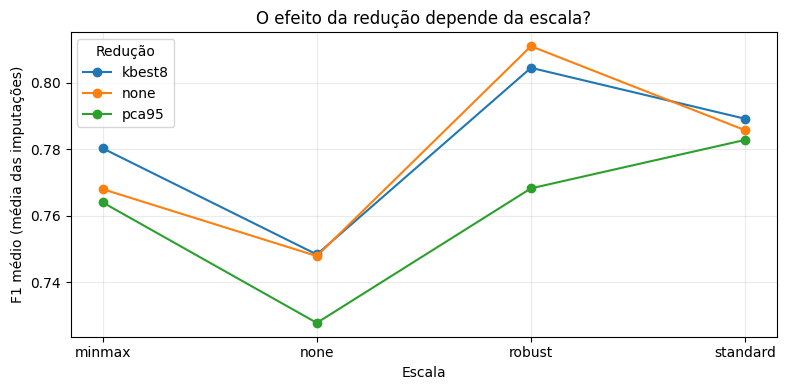

In [10]:
interaction = valid.pivot_table(index='scale', columns='reduction', values='f1_mean', aggfunc='mean')
display(interaction.round(4))
fig, ax = plt.subplots(figsize=(8, 4))
for reduction in interaction.columns:
    ax.plot(interaction.index, interaction[reduction], marker='o', label=reduction)
ax.set(title='O efeito da redução depende da escala?', xlabel='Escala', ylabel='F1 médio (média das imputações)')
ax.legend(title='Redução'); ax.grid(alpha=.25)
plt.tight_layout(); plt.show()

As linhas não são paralelas: a redução interage com a escala. Sem redução, Robust tem F1 médio **0,8110**, mas com PCA cai para **0,7682**. Standard muda de **0,7857** para **0,7828**, uma diferença pequena frente à variabilidade. Com MinMax, SelectKBest tem **0,7803**, contra **0,7680** sem redução; os resultados individuais e seus DPs ainda precisam acompanhar essa diferença. Hipótese explicativa: PCA nos dados sem escala ou com Robust concentra variância em poucos componentes e pode perder informação discriminativa. Os 2–4 componentes observados nesse contexto são compatíveis com essa hipótese, mas não comprovam a causa. O gráfico agrega as duas imputações e não traz intervalos de incerteza; os DPs estão nas tabelas anteriores.

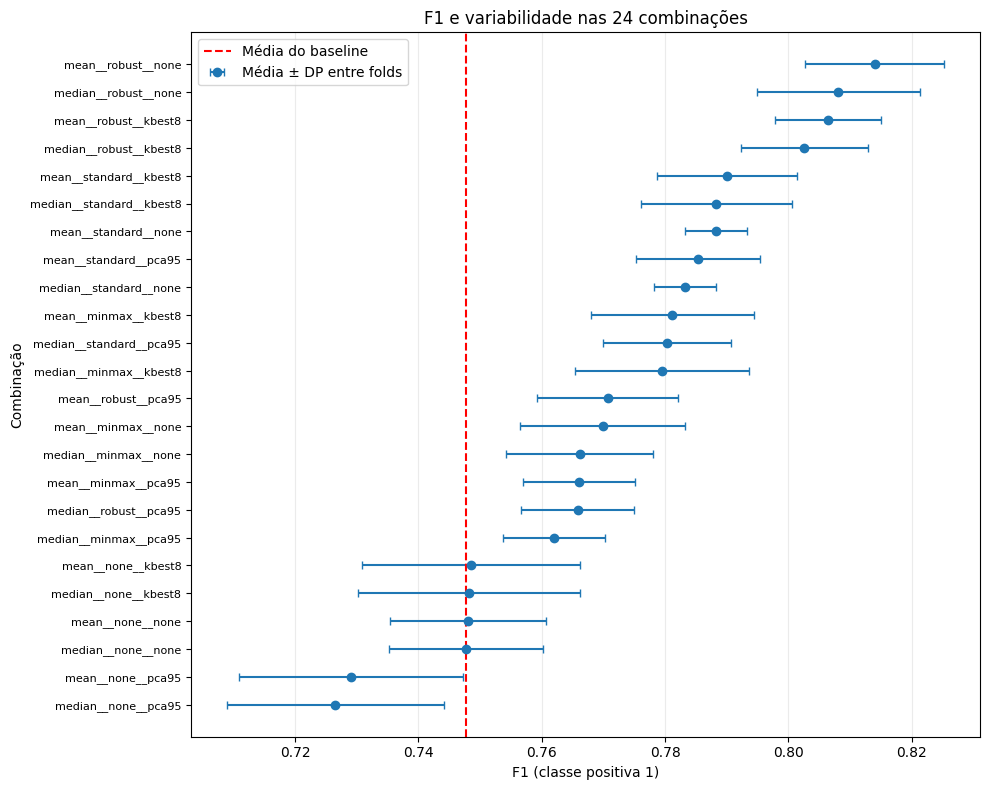

In [11]:
fig, ax = plt.subplots(figsize=(10, 8))
order = valid.sort_values('f1_mean')
ax.errorbar(order.f1_mean, range(len(order)), xerr=order.f1_std, fmt='o', capsize=3, label='Média ± DP entre folds')
ax.set_yticks(range(len(order)), order.combination, fontsize=8)
ax.axvline(base.f1_mean, color='red', linestyle='--', label='Média do baseline')
ax.set(title='F1 e variabilidade nas 24 combinações', xlabel='F1 (classe positiva 1)', ylabel='Combinação')
ax.legend(); ax.grid(axis='x', alpha=.25)
plt.tight_layout(); plt.show()

As barras representam **um desvio-padrão entre folds**, não intervalos de confiança. O maior F1 médio supera o baseline pela regra adotada, mas não distingue com segurança todas as opções próximas no topo. Média/Robust/sem redução e mediana/Robust/sem redução diferem em 0,0059, menos que o maior DP (0,0132): empate. A mera sobreposição visual das barras não substitui a regra numérica de comparação; tampouco a ausência de sobreposição seria um teste formal. A ordenação serve para examinar padrões, sem declarar um vencedor único.

,combination,seconds_total,f1_mean,f1_std
18,median__minmax__none,1.5612,0.7661,0.0119
15,median__standard__none,1.5427,0.7832,0.0050
23,median__robust__kbest8,1.3940,0.8026,0.0103
16,median__standard__pca95,1.3576,0.7803,0.0103
21,median__robust__none,1.3421,0.8081,0.0132
14,median__none__kbest8,1.3154,0.7481,0.0180


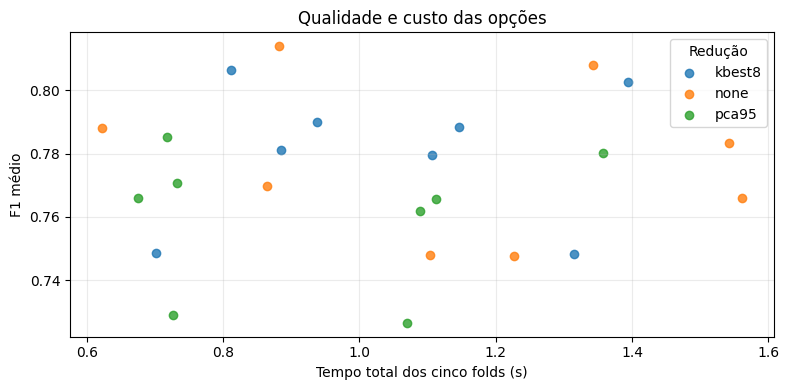

In [12]:
slow = valid.sort_values('seconds_total', ascending=False)
display(slow[['combination', 'seconds_total', 'f1_mean', 'f1_std']].head(6).round(4))
fig, ax = plt.subplots(figsize=(8, 4))
for reduction, part in valid.groupby('reduction'):
    ax.scatter(part.seconds_total, part.f1_mean, label=reduction, alpha=.8)
ax.set(title='Qualidade e custo das opções', xlabel='Tempo total dos cinco folds (s)', ylabel='F1 médio')
ax.legend(title='Redução'); ax.grid(alpha=.25)
plt.tight_layout(); plt.show()

A opção mais lenta nesta execução foi **`median__minmax__none`**, com **1.561 s** nos cinco folds. O total de todas as combinações foi **24.925 s**, e os custos individuais variaram de **0.623 a 1.561 s**. PCA teve custo marginal médio de 0,935 s por combinação, seleção 1,037 s e nenhuma redução 1,143 s. A maior média de F1 custou 0.882 s, contra 1.226 s do baseline, mas não concluímos que a imputação pela média é computacionalmente mais rápida: as combinações com média foram executadas antes das de mediana, e carga/cache podem influenciar. A redução pode acelerar distâncias ao diminuir dimensões, porém adiciona custo de ajuste. Como os tempos são curtos e não foram repetidos em ordem aleatória, são registros de custo observado, não evidência estável de vantagem de velocidade.

## 12. Conclusão: resultados, hipóteses e limitações

Nesta execução, a mudança mais consistente foi incluir escala: o kNN preservado teve maior F1 nas opções escaladas que nas correspondentes sem escala. O maior F1 médio observado foi **0.8140 ± 0.0113**, em média/Robust/sem redução, contra **0.7477 ± 0.0125** do baseline. Há empates entre alternativas próximas, portanto não elegemos uma configuração única como superior. A imputação teve efeito pequeno; PCA apresentou perda mais forte com Robust e sem escala, indicando que a redução não deve ser considerada isoladamente. SelectKBest não trouxe ganho uniforme.

A EDA motivou a hipótese de que extremos favorecessem a mediana, mas os pequenos ganhos medidos para a média não a confirmam nem demonstram superioridade da média. O desempenho de Robust é compatível com a hipótese de que escalas menos afetadas pelo IQR ajudem a distância; ainda preservamos extremos e não atribuímos causalidade ao mecanismo. A relação entre redução e escala é uma hipótese a aprofundar. Todas as 24 combinações completaram cinco folds sem falhas; os custos medidos ficam registrados e devem ser interpretados com as limitações de ordem e carga mencionadas acima.

A validação por estrela reduz compartilhamento de informação entre treino e teste, mas continua avaliando um único catálogo e sua classificação. Ausências, extremos e parâmetros de ajustes podem carregar características do processo de catalogação. Não medimos desempenho em observações futuras ou em outra população de estrelas. Não afirmamos descoberta ou confirmação de exoplanetas.

O resultado é condicionado ao kNN fixo, aos cinco folds, ao recorte e à semente. A ordenação entre 24 alternativas não constitui avaliação independente da alternativa escolhida: uma futura seleção para implantação exigiria validação externa. Tempos variam com hardware, carga e ordem de execução. Hipóteses explicativas sobre escalas, extremos e redundância precisam de novos experimentos controlados; não são relações causais demonstradas.

### Conferência e reprodução
Execute todas as células na ordem, com o ambiente do README, a partir da raiz ou de `notebooks/`. `results/preprocessing_fold_assignments.csv` identifica exatamente os conjuntos: o fold indicado é teste, todos os outros são treino. Os CSVs guardam métricas em escala [0,1], tempos em segundos e o esquema de validação; o JSON registra versões, hash e parâmetros.

Fonte dos dados e referência acadêmica: Entrega 1, `notebooks/01_eda.ipynb`; NASA Exoplanet Archive, KOI Cumulative, DOI **10.26133/NEA4**, snapshot local de 30/09/2026. Não houve nova extração.

In [13]:
expected_csvs = {'preprocessing_folds.csv': 120, 'preprocessing_summary.csv': 24,
                 'preprocessing_fold_scheme.csv': 5, 'preprocessing_fold_assignments.csv': 9564,
                 'preprocessing_baseline_comparison.csv': len(valid),
                 'preprocessing_paired_effects.csv': len(paired)}
for filename, expected_rows in expected_csvs.items():
    checked = pd.read_csv(RESULTS / filename)
    assert len(checked) == expected_rows, filename
assert sha256((ROOT / 'notebooks' / '01_eda.ipynb').read_bytes()).hexdigest() == EDA_HASH
assert sha256(CSV.read_bytes()).hexdigest() == DATA_HASH
print('CSV legíveis:', len(expected_csvs))
print('24 combinações com 5 registros por combinação; falhas registradas quando existentes.')
print('EDA e snapshot permanecem intactos.')

CSV legíveis: 6
24 combinações com 5 registros por combinação; falhas registradas quando existentes.
EDA e snapshot permanecem intactos.
